In [ ]:
!pip install mysql-connector-python

In [24]:
import mysql.connector
import pandas as pd 

In [25]:
conn = mysql.connector.connect(
    host="localhost", 
    user="root", 
    password="mr.abhi1149", 
    database="python_db"
)

In [26]:
q = "select * from covid_toy"

In [27]:
df = pd.read_sql(q, conn)
df.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_28732\873776951.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn)


,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [28]:
df.isnull().sum()

age          0
gender       0
fever        0
cough        0
city         0
has_covid    0
dtype: int64

In [29]:
# from sklearn.impute import SimpleImputer

# imputer = SimpleImputer(strategy="most_frequent")

# df[["City"]] = imputer.fit_transform(df[["City"]])

In [30]:
df.duplicated().sum()

np.int64(1)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        90 non-null     int64  
 1   gender     90 non-null     str    
 2   fever      90 non-null     float64
 3   cough      90 non-null     str    
 4   city       90 non-null     str    
 5   has_covid  90 non-null     str    
dtypes: float64(1), int64(1), str(4)
memory usage: 4.3 KB


In [32]:
df.drop_duplicates(inplace=True)

In [33]:
cat_col = df.select_dtypes(include='str')

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [35]:
for i in cat_col: 
    df[i] = le.fit_transform(df[i])

In [36]:
df.describe()

,age,gender,fever,cough,city,has_covid
count,89.000000,89.000000,89.000000,89.000000,89.000000,89.00000
mean,43.224719,0.393258,100.853933,0.370787,1.303371,0.41573
std,24.731170,0.491241,2.064585,0.485752,1.070307,0.49564
min,5.000000,0.000000,98.000000,0.000000,0.000000,0.00000
25%,19.000000,0.000000,99.000000,0.000000,0.000000,0.00000
50%,46.000000,0.000000,101.000000,0.000000,1.000000,0.00000
75%,65.000000,1.000000,103.000000,1.000000,2.000000,1.00000
max,83.000000,1.000000,104.000000,1.000000,3.000000,1.00000


In [41]:
x = df.drop(columns=['has_covid'])
y = df['has_covid']

In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [45]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [46]:
x_train_scaled = sc.fit_transform(x_train) 
x_test_scaled = sc.transform(x_test)

In [47]:
import matplotlib.pyplot as plt 
import seaborn as sns

C:\Users\pc\AppData\Local\Temp\ipykernel_28732\10025218.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train)


<Axes: ylabel='Density'>

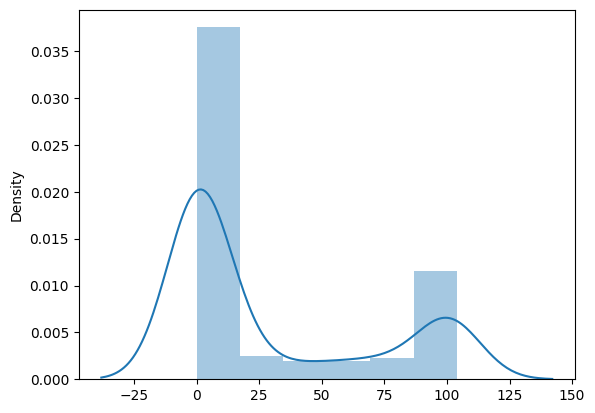

In [48]:
sns.distplot(x_train)

C:\Users\pc\AppData\Local\Temp\ipykernel_28732\2164567946.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_scaled)


<Axes: ylabel='Density'>

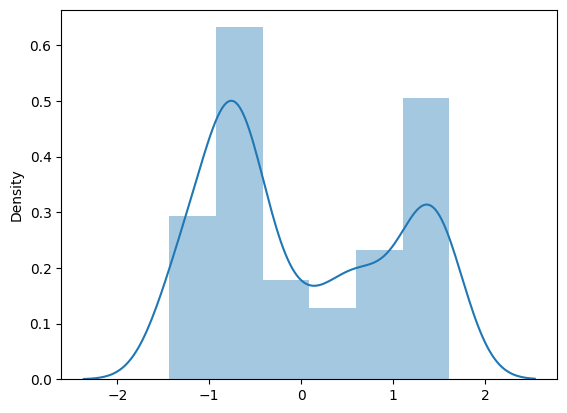

In [49]:
sns.distplot(x_train_scaled)